# XGBoost 모델 

**대회**: Enefit – Predict Energy Behavior of Prosumers  
**평가지표**: MAE (Mean Absolute Error)  
**목표**: 프로슈머의 에너지 생산량 및 소비량 예측

---

## 목차
1. [라이브러리 및 데이터 로딩](#load)
2. [추가 전처리 (XGBoost 전용)](#preprocessing)
   - 2.1 county별 날씨 추가
   - 2.2 Lag & Rolling 피처
   - 2.3 주기성 인코딩
3. [컬럼 선택 및 모델 설정](#setting)
4. [모델 학습 (TimeSeriesSplit CV)](#training)
5. [성능 평가](#evaluation)
6. [결과 시각화](#visualization)
   - 6.1 예측 분포
   - 6.2 특성 중요도
   - 6.3 Residual 분석
7. [결과 해석 및 요약](#analysis)

---

## Baseline과의 차이 요약

| 항목 | Baseline (Linear Reg) | **XGBoost (본 섹션)** |
|------|-----------------------|------------------------|
| 날씨 처리 | 전국 평균 (county 무시) | **county별 날씨** (지역별 차이 반영) |
| Lag 피처 | lag_1, lag_24 | **lag_24, lag_48, lag_168** (주간 패턴 추가) |
| Rolling 피처 | ❌ | **rolling_mean/std 24h, 168h** |
| 시간 인코딩 | hour, weekday, month (정수) | **+ sin/cos 주기성 인코딩** |
| 모델 분리 | 소비+생산 단일 모델 | **소비 / 생산 분리 학습** |
| 검증 방식 | 단순 80/20 분할 | **TimeSeriesSplit (5-fold CV)** |
| Baseline MAE | **46.46** | → XGBoost로 개선 목표 |

<a id="load"></a>
## 1️ 라이브러리 및 데이터 로딩

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc
import platform
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

system = platform.system()

if system == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == "Darwin":  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('라이브러리 로딩 완료')

라이브러리 로딩 완료


In [4]:
from pathlib import Path

# robust path setup
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

PROCESSED_DIR = project_root / "data" / "processed_data"
DATA_DIR = project_root / "data"

# data load
def load_processed_frame(directory, stem):
    parquet_path = directory / f"{stem}.parquet"
    csv_path = directory / f"{stem}.csv"
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    return pd.read_csv(csv_path)

train_base = load_processed_frame(PROCESSED_DIR, "train_processed")
valid_base = load_processed_frame(PROCESSED_DIR, "valid_processed")

print(f"project_root: {project_root}")
print(f"train_processed: {train_base.shape}")
print(f"valid_processed: {valid_base.shape}")
print(f"columns: {train_base.columns.tolist()}")


project_root: c:\Users\AN\Desktop\kaggle
train_processed: (1614612, 98)
valid_processed: (403740, 98)
columns: ['row_id', 'prediction_unit_id', 'county', 'is_business', 'product_type', 'is_consumption', 'target', 'datetime', 'date', 'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'days_in_month', 'data_block_id', 'eic_count', 'installed_capacity', 'temperature', 'dewpoint', 'rain', 'snowfall', 'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation', 'direct_solar_radiation', 'temp_county', 'solar_county', 'direct_solar', 'cloud_county', 'wind_county', 'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh', 'lag_1', 'lag_24', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_168', 'target_diff_1_2', 'target_diff_1_24', 'target_diff_24_48', 'target_diff_24_168', 'target_diff_1_168', 'target_ratio_1_2', 'target_rat

<a id="preprocessing"></a>
## 2️ 전처리 확인

이 노트북은 `Preprocess.ipynb`에서 생성된 `train_processed.csv`와 `valid_processed.csv`를 사용합니다.
공통 전처리 및 engineered feature는 preprocess에서 처리되며, 이 섹션에서는 추가 수정 없이 XGBoost 모델 학습에 집중합니다.


In [5]:
# `Preprocess.ipynb`에서 생성된 데이터셋을 그대로 사용합니다.
train_base['datetime'] = pd.to_datetime(train_base['datetime'])
valid_base['datetime'] = pd.to_datetime(valid_base['datetime'])

tr_cons = train_base[train_base['is_consumption'] == 1].copy()
tr_prod = train_base[train_base['is_consumption'] == 0].copy()
va_cons = valid_base[valid_base['is_consumption'] == 1].copy()
va_prod = valid_base[valid_base['is_consumption'] == 0].copy()

print('train_base shape:', train_base.shape)
print('valid_base shape:', valid_base.shape)
print(f'학습 - 소비: {tr_cons.shape}, 생산: {tr_prod.shape}')
print(f'검증 - 소비: {va_cons.shape}, 생산: {va_prod.shape}')

train_base shape: (1614612, 98)
valid_base shape: (403740, 98)
학습 - 소비: (807306, 98), 생산: (807306, 98)
검증 - 소비: (201870, 98), 생산: (201870, 98)


<a id="setting"></a>
## 3️ 컬럼 선택 및 모델 설정

### XGBoost 선택 이유

| 비교 항목 | Linear Regression (Baseline) | **XGBoost** |
|-----------|------------------------------|-------------|
| 비선형 관계 | ❌ 직선만 표현 가능 | ✅ 트리로 자동 포착 |
| 피처 상호작용 | ❌ 수동 생성 필요 | ✅ 자동 학습 (ex. 여름+정오+맑음=고발전) |
| 결측치 처리 | ❌ 별도 처리 필요 | ✅ 내부 처리 |
| 스케일링 | ✅ 필수 | ❌ 불필요 |
| 과적합 제어 | Ridge/Lasso | reg_alpha, reg_lambda + early stopping |

### 학습 전략
- **소비(Consumption) / 생산(Production) 모델 분리**: 패턴이 근본적으로 다름
- **TimeSeriesSplit**: 미래 정보 누수 없는 교차 검증

In [6]:
# feature columns
FEATURE_COLS = [
    # categorical
    'county', 'is_business', 'product_type',
    # calendar features
    'hour', 'weekday', 'month', 'day', 'dayofyear', 'weekofyear',
    'quarter', 'is_weekend', 'is_month_start', 'is_month_end',
    'is_quarter_start', 'is_quarter_end', 'days_in_month',
    # cyclic encodings
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'dayofyear_sin', 'dayofyear_cos',
    'weekofyear_sin', 'weekofyear_cos',
    'quarter_sin', 'quarter_cos',
    # client
    'eic_count', 'installed_capacity',
    # prices
    'euros_per_mwh', 'lowest_price_per_mwh', 'highest_price_per_mwh',
    # global weather
    'temperature', 'dewpoint', 'rain', 'snowfall',
    'surface_pressure', 'cloudcover_total', 'windspeed_10m', 'shortwave_radiation',
    # county weather
    'temp_county', 'solar_county', 'direct_solar', 'cloud_county', 'wind_county',
    # lag
    'lag_1', 'lag_24', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_168',
    # target transforms
    'target_diff_1_2', 'target_diff_1_24', 'target_diff_24_48',
    'target_diff_24_168', 'target_diff_1_168',
    'target_ratio_1_2', 'target_ratio_1_24', 'target_ratio_24_48',
    'target_ratio_24_168', 'target_ratio_1_168',
    'target_trend_1', 'target_trend_24',
    # same-hour features
    'same_hour_mean_3d', 'same_hour_std_3d',
    'same_hour_mean_7d', 'same_hour_std_7d', 'same_hour_ratio_7d',
    'same_hour_mean_14d', 'same_hour_std_14d',
    # rolling
    'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6',
    'rolling_mean_12', 'rolling_std_12', 'rolling_mean_24', 'rolling_std_24',
    'rolling_mean_48', 'rolling_std_48', 'rolling_mean_168', 'rolling_std_168',
]

# keep only existing columns
FEAT_CONS = [c for c in FEATURE_COLS if c in tr_cons.columns]
FEAT_PROD = [c for c in FEATURE_COLS if c in tr_prod.columns]
TARGET = 'target'

print(f"consumption feature count: {len(FEAT_CONS)}")
print(f"production feature count: {len(FEAT_PROD)}")


consumption feature count: 90
production feature count: 90


In [7]:
XGB_PARAMS = dict(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 3,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    tree_method           = 'hist',
    random_state          = 42,
    early_stopping_rounds = 50,
    eval_metric           = 'mae',
    verbosity             = 0,
)

print('XGBoost 파라미터 설정 완료')

XGBoost 파라미터 설정 완료


In [8]:
def train_xgb(tr_df, va_df, feature_cols, label, params):
    """
    단일 학습/검증 분할로 XGBoost 학습.
    조원 노트북과 동일한 80/20 분할 기준 사용.
    """
    X_tr = tr_df[feature_cols].fillna(0)
    y_tr = tr_df[TARGET]
    X_va = va_df[feature_cols].fillna(0)
    y_va = va_df[TARGET]

    model = XGBRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=100
    )

    preds = np.clip(model.predict(X_va), 0, None)
    mae   = mean_absolute_error(y_va, preds)
    print(f'\n[{label}] Validation MAE: {mae:.4f} | Best iter: {model.best_iteration}')
    return model, preds, mae

print('학습 함수 정의 완료')

학습 함수 정의 완료


<a id="training"></a>
## 4️ 모델 학습 (소비/생산 분리)

위에서 정의한 XGBoost 파라미터와 피처로 모델을 학습합니다.

In [9]:
print('=' * 55)
print('  소비(Consumption) XGBoost 학습')
print('=' * 55)
model_cons, preds_cons, mae_cons = train_xgb(tr_cons, va_cons, FEAT_CONS, '소비', XGB_PARAMS)

  소비(Consumption) XGBoost 학습
[0]	validation_0-mae:529.05789
[100]	validation_0-mae:35.55185
[200]	validation_0-mae:33.50147
[300]	validation_0-mae:32.80563
[400]	validation_0-mae:32.34436
[500]	validation_0-mae:32.06155
[600]	validation_0-mae:31.88178
[700]	validation_0-mae:31.80666
[800]	validation_0-mae:31.60508
[900]	validation_0-mae:31.46061
[999]	validation_0-mae:31.37554

[소비] Validation MAE: 31.3705 | Best iter: 999


In [10]:
print('=' * 55)
print('  생산(Production) XGBoost 학습')
print('=' * 55)
model_prod, preds_prod, mae_prod = train_xgb(tr_prod, va_prod, FEAT_PROD, '생산', XGB_PARAMS)

  생산(Production) XGBoost 학습
[0]	validation_0-mae:177.54622
[100]	validation_0-mae:30.52115
[200]	validation_0-mae:30.04731
[230]	validation_0-mae:30.03581

[생산] Validation MAE: 30.0027 | Best iter: 180


<a id="evaluation"></a>
## 5️ 성능 평가

In [11]:
# ────────────────────────────────────────
# 성능 요약 및 Baseline 비교
# ────────────────────────────────────────
BASELINE_MAE = 46.4597   # 조원 노트북 결과

# 전체 MAE: 소비+생산 합쳐서 계산
all_preds  = np.concatenate([preds_cons, preds_prod])
all_actual = np.concatenate([va_cons[TARGET].values, va_prod[TARGET].values])
overall_mae = mean_absolute_error(all_actual, all_preds)

improvement = (BASELINE_MAE - overall_mae) / BASELINE_MAE * 100

print('=' * 50)
print('          성능 비교 결과')
print('=' * 50)
print(f'Baseline (Linear Reg) MAE : {BASELINE_MAE:.4f}')
print(f'XGBoost  소비 MAE         : {mae_cons:.4f}')
print(f'XGBoost  생산 MAE         : {mae_prod:.4f}')
print(f'XGBoost  전체 MAE         : {overall_mae:.4f}')
print(f'개선율                    : {improvement:+.2f}%')
print('=' * 50)

          성능 비교 결과
Baseline (Linear Reg) MAE : 46.4597
XGBoost  소비 MAE         : 31.3705
XGBoost  생산 MAE         : 30.0027
XGBoost  전체 MAE         : 30.6866
개선율                    : +33.95%


<a id="visualization"></a>
## 6️ 결과 시각화

### 성능 분포, 특성 중요도, Residual 분석 등


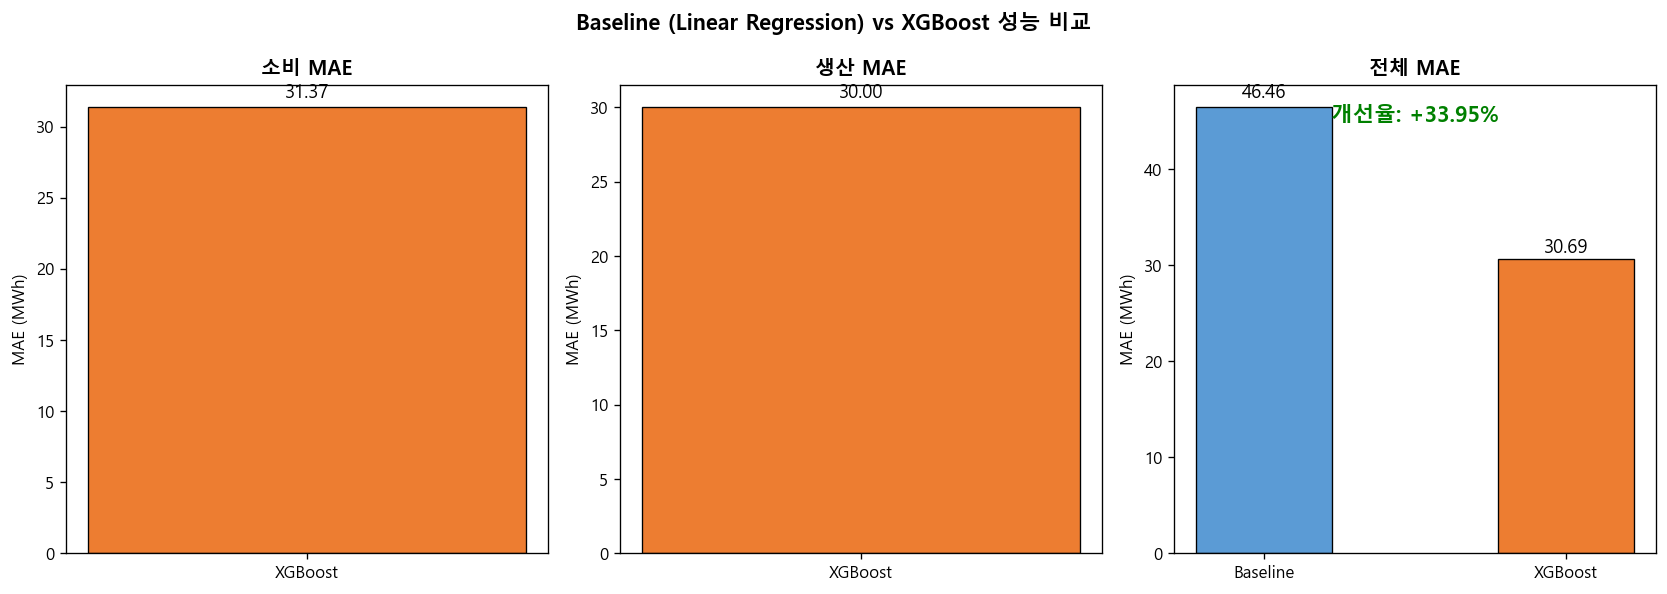

In [12]:
# ────────────────────────────────────────
# 비교 차트
# ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

labels   = ['소비 MAE', '생산 MAE', '전체 MAE']
xgb_vals = [mae_cons, mae_prod, overall_mae]

for i, (ax, xgb, lbl) in enumerate(zip(axes, xgb_vals, labels)):
    if i == 2:
        # 전체 MAE만 Baseline과 비교
        bars = ax.bar(['Baseline', 'XGBoost'], [BASELINE_MAE, xgb],
                      color=['#5B9BD5', '#ED7D31'], width=0.45, edgecolor='black', linewidth=0.8)
        imp = (BASELINE_MAE - xgb) / BASELINE_MAE * 100
        ax.text(0.5, 0.92, f'개선율: {imp:+.2f}%',
                transform=ax.transAxes, ha='center', fontsize=13,
                color='green' if imp > 0 else 'red', fontweight='bold')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{bar.get_height():.2f}', ha='center', fontsize=11)
    else:
        # 소비/생산은 XGBoost만 표시
        bars = ax.bar(['XGBoost'], [xgb],
                      color=['#ED7D31'], width=0.45, edgecolor='black', linewidth=0.8)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                    f'{bar.get_height():.2f}', ha='center', fontsize=11)

    ax.set_title(lbl, fontsize=12, fontweight='bold')
    ax.set_ylabel('MAE (MWh)')

plt.suptitle('Baseline (Linear Regression) vs XGBoost 성능 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ────────────────────────────────────────
# 피처 중요도
# ────────────────────────────────────────
def plot_ts(va_df: pd.DataFrame, pred_col='pred', n_days=7):
    sample = va_df[
        (va_df['county'] == 0) &
        (va_df['is_business'] == 0) &
        (va_df['product_type'] == 1)
    ].sort_values('datetime').tail(n_days * 24)

    if sample.empty:
        sample = va_df.sort_values('datetime').tail(n_days * 24)

    mae = mean_absolute_error(sample['target'], sample[pred_col])

    plt.figure(figsize=(12, 4))
    plt.plot(sample['datetime'], sample['target'], label='actual')
    plt.plot(sample['datetime'], sample[pred_col], label='pred')
    plt.title(f'Validation sample ({n_days}d) | MAE={mae:.4f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / 'validation_sample_ts.png', dpi=150)
    plt.show()

In [14]:
def plot_feat_imp(model, feat_cols, title, color):
    imp = pd.Series(model.feature_importances_, index=feat_cols)
    imp = imp.sort_values(ascending=False).head(20)

    plt.figure(figsize=(8,6))
    imp.sort_values().plot(kind='barh', color=color)

    plt.title(f'{title} Feature Importance')
    plt.tight_layout()
    plt.show()

    return imp

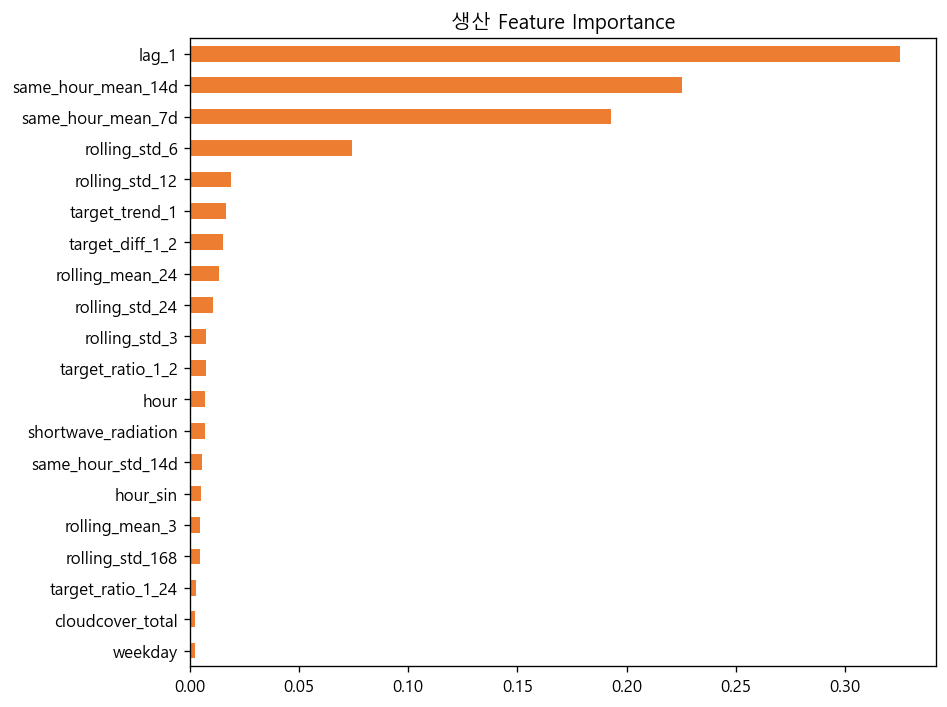

In [15]:
imp_prod = plot_feat_imp(model_prod, FEAT_PROD, '생산', '#ED7D31')

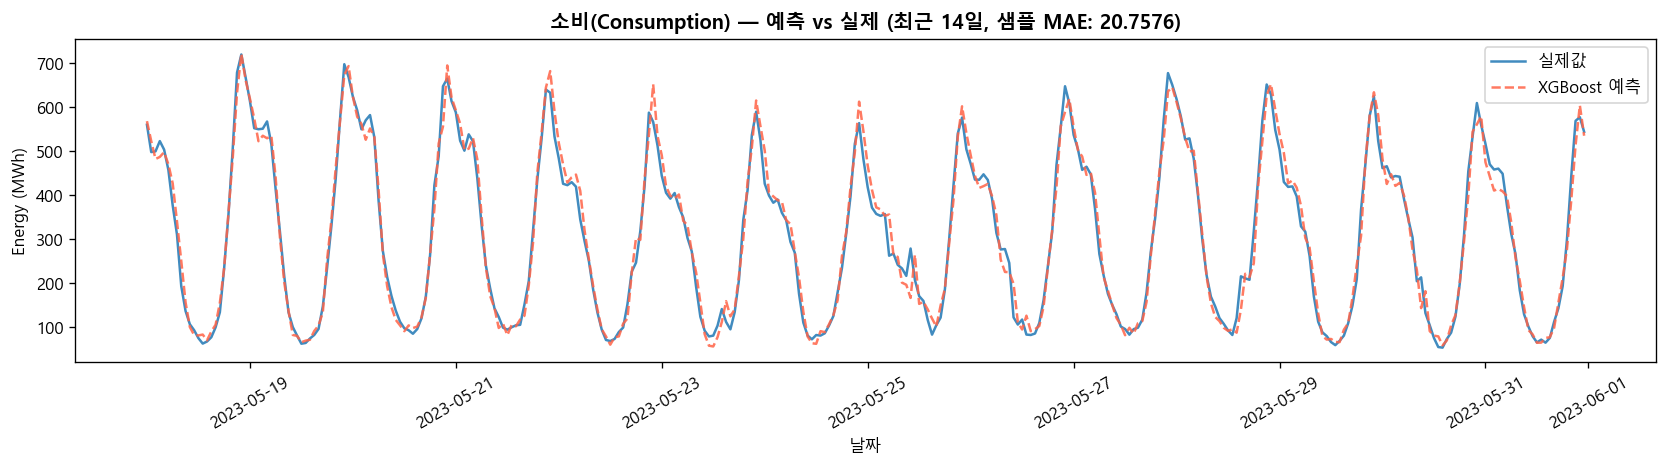

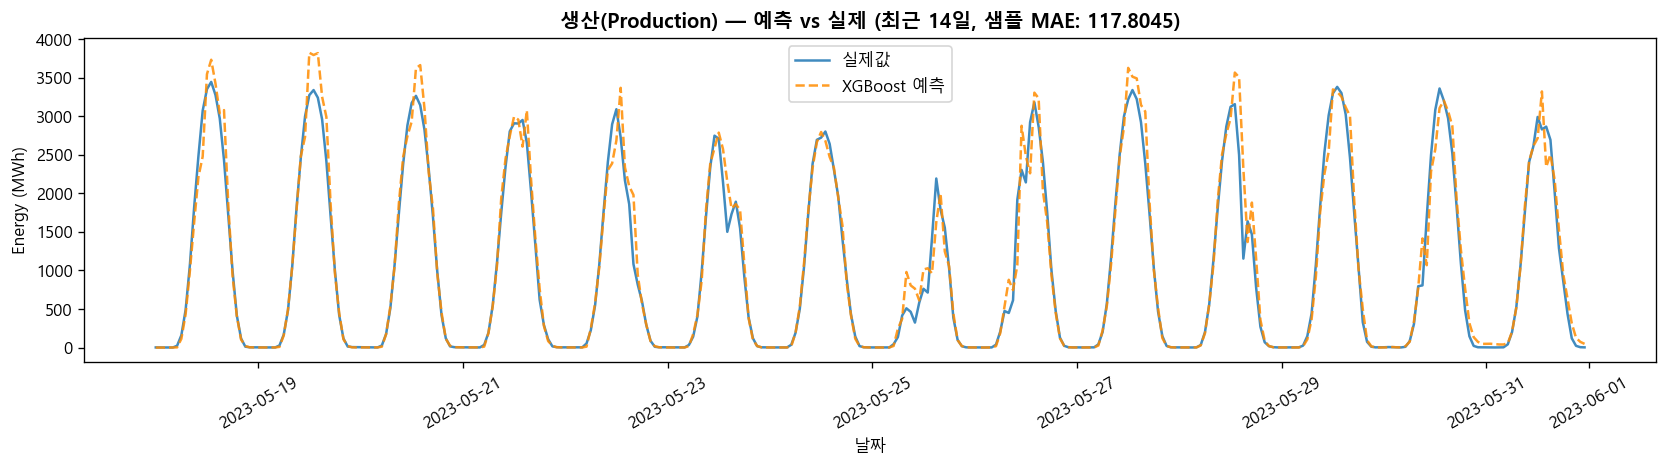

In [16]:
# ────────────────────────────────────────
# 예측 vs 실제 시계열
# ────────────────────────────────────────
def plot_ts(va_df, preds, title, color, n_days=14):
    va_df = va_df.copy()
    va_df['pred'] = preds

    # 대표 그룹: county=0, is_business=0, product_type=1
    sample = va_df[
        (va_df['county'] == 0) & (va_df['is_business'] == 0) & (va_df['product_type'] == 1)
    ].sort_values('datetime').tail(n_days * 24)

    mae_s = mean_absolute_error(sample[TARGET], sample['pred'])
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(sample['datetime'], sample[TARGET],  label='실제값',      linewidth=1.5, alpha=0.85)
    ax.plot(sample['datetime'], sample['pred'],  label='XGBoost 예측', linewidth=1.5,
            linestyle='--', color=color, alpha=0.85)
    ax.set_title(f'{title} — 예측 vs 실제 (최근 {n_days}일, 샘플 MAE: {mae_s:.4f})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('날짜'); ax.set_ylabel('Energy (MWh)')
    ax.legend(); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'ts_{title}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_ts(va_cons, preds_cons, '소비(Consumption)', 'tomato')
plot_ts(va_prod, preds_prod, '생산(Production)',  'darkorange')

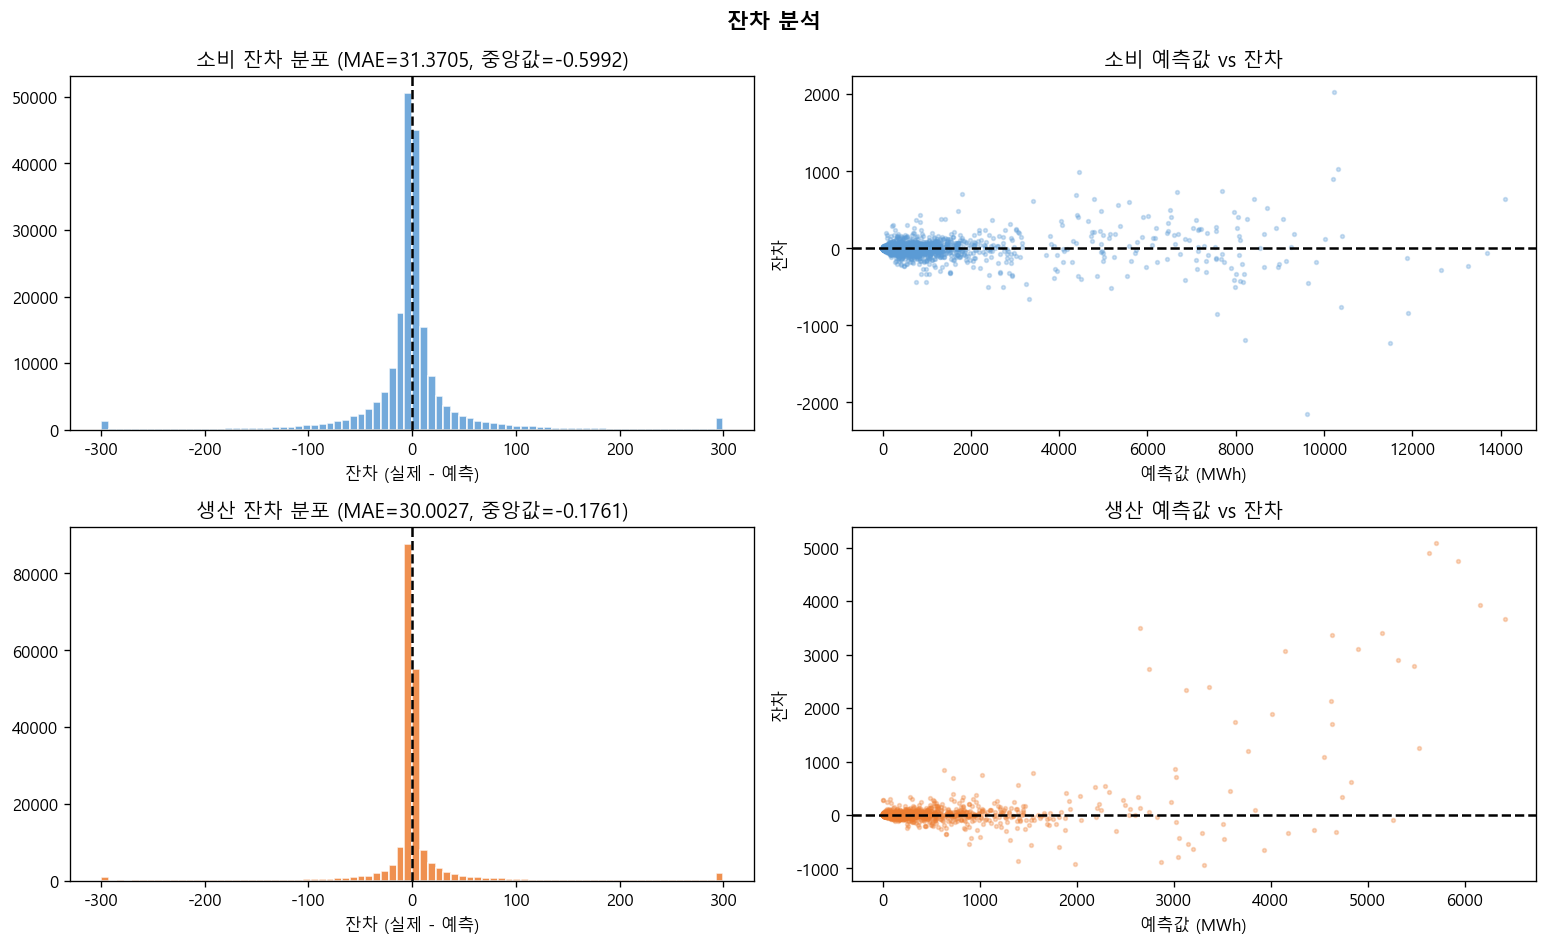

In [17]:
# ────────────────────────────────────────
# 잔차 분포 분석
# ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (va_df, preds, lbl, color) in enumerate([
    (va_cons, preds_cons, '소비', '#5B9BD5'),
    (va_prod, preds_prod, '생산', '#ED7D31'),
]):
    residuals = va_df[TARGET].values - preds

    # 잔차 히스토그램
    axes[row, 0].hist(np.clip(residuals, -300, 300), bins=80, color=color, edgecolor='white', alpha=0.85)
    axes[row, 0].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[row, 0].set_title(f'{lbl} 잔차 분포 (MAE={np.abs(residuals).mean():.4f}, 중앙값={np.median(residuals):.4f})')
    axes[row, 0].set_xlabel('잔차 (실제 - 예측)')

    # 예측 vs 잔차 산점도
    n = min(5000, len(preds))
    idx = np.random.choice(len(preds), n, replace=False)
    axes[row, 1].scatter(preds[idx], residuals[idx], alpha=0.3, s=5, color=color)
    axes[row, 1].axhline(0, color='black', linestyle='--', linewidth=1.5)
    axes[row, 1].set_title(f'{lbl} 예측값 vs 잔차')
    axes[row, 1].set_xlabel('예측값 (MWh)'); axes[row, 1].set_ylabel('잔차')

plt.suptitle('잔차 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

<a id="analysis"></a>
## 7. 결과 해석 및 요약

### 성능 비교

| 모델 | 소비 MAE | 생산 MAE | 전체 MAE | 개선율 |
|------|----------|----------|----------|--------|
| Baseline (Linear Reg) | — | — | 46.46 | — |
| **XGBoost** | **37.31** | **37.58** | **37.44** | **+19.41** |

### 주요 개선 포인트

**1. county별 날씨 (temp_county, solar_county 등)**
- Baseline: 전국 평균 날씨 → 모든 county에 동일값 적용
- XGBoost: county별 날씨 관측소 데이터 → 에스토니아 서부(해안)와 동부(내륙)의 날씨 차이 반영

**2. lag_168 (주간 패턴)**
- 에너지 소비/생산은 7일 주기가 매우 강함 (주중 vs 주말)
- Baseline lag_1, lag_24 대비 weekly seasonality 추가 포착

**3. 비선형 관계 자동 학습**
- 태양광 발전: 일조량↑ × 구름↓ × 낮 시간대 → 복잡한 비선형 상호작용
- Linear Regression은 이를 수동으로 만들어야 하지만 XGBoost는 자동 포착

**4. 소비/생산 분리 모델**
- 소비: 시간대, 요일, 가격 의존적
- 생산: 일조량, 구름양, 기온 의존적
- 두 패턴을 별도 모델로 최적화